# Error Analysis & Model Explainability

## Checking GPU Usage

Go to the `Runtime > Change runtime type` menu and check that we're on Python 3 and that the hardware accelerator is set to "GPU".

In [1]:
!nvidia-smi

Wed Oct  7 16:05:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:04:00.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Downloading the Data

In [2]:
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s landscape

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 24289, done.
remote: Counting objects: 100% (24289/24289), done.
remote: Compressing objects: 100% (24289/24289), done.
remote: Total 24289 (delta 0), reused 24289 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24289/24289), 341.65 MiB | 5.27 MiB/s, done.
Updating files: 100% (24336/24336), done.
✓ landscape — 24336 fichiers, 401M


## Importing TensorFlow and the Other Required Libraries

In [3]:
!pip install shap
import itertools
import pathlib
import typing

import matplotlib.pyplot as plt
import numpy
import PIL.Image
import seaborn
import shap
import sklearn.metrics
import tensorflow as tf
import tensorflow.keras as keras
import tqdm.notebook

## Preparing the Data

To load our data, we'll combine several libraries: [Pillow](https://pillow.readthedocs.io/) (`PIL`), [NumPy](https://numpy.org/) and [TensorFlow](https://www.tensorflow.org/). These libraries will be called from the `get_images` function.

Each image is loaded with PIL, then resized to 150x150; finally, by default, we'll return a dataset shuffled with [`tf.random.shuffle`](https://www.tensorflow.org/api_docs/python/tf/random/shuffle).

In [4]:
INPUT_SHAPE = (150, 150)


label_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
label_to_index = {l: i for i, l in enumerate(label_names)}


def get_images(dir_path: pathlib.Path,
               shuffle: bool = True,
               create_labels: bool = True,
               ) -> typing.Tuple[tf.Tensor, tf.Tensor]:
  images = []
  if create_labels:
    labels = []

  # Iterate over the subfolders of the root: each one matches a
  # class
  for subdir_path in tqdm.notebook.tqdm(
      list(dir_path.iterdir()), desc="Processing folders"):

    dir_name = subdir_path.name

    if create_labels:
      # Assign the right label based on the folder name "labels"
      label = label_to_index.get(dir_name)

    # Add each image of the current label (folder) to our dataset
    for image_path in tqdm.notebook.tqdm(
        list(subdir_path.iterdir()), desc=f"Folder {dir_name}", leave=False):
      # Use PIL to load the image
      images.append(
          numpy.array(PIL.Image.open(image_path).resize(INPUT_SHAPE)))
      if create_labels:
        labels.append(label)

  images = tf.constant(numpy.array(images))
  if create_labels:
    labels = tf.constant(numpy.array(labels))

  if shuffle:
    perm = tf.random.shuffle(tf.range(images.shape[0]))
    images = tf.gather(images, perm)
    if create_labels:
      labels = tf.gather(labels, perm)

  if create_labels:
    return images, labels
  else:
    return images

## Calling `get_images`

In [5]:
images, labels = get_images(pathlib.Path("landscape") / "seg_train")

Processing folders:   0%|          | 0/6 [00:00<?, ?it/s]

Folder buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Folder forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Folder glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Folder mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Folder sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Folder street:   0%|          | 0/2382 [00:00<?, ?it/s]

Images shape:  (14034, 150, 150, 3)
Labels shape:  (14034,)


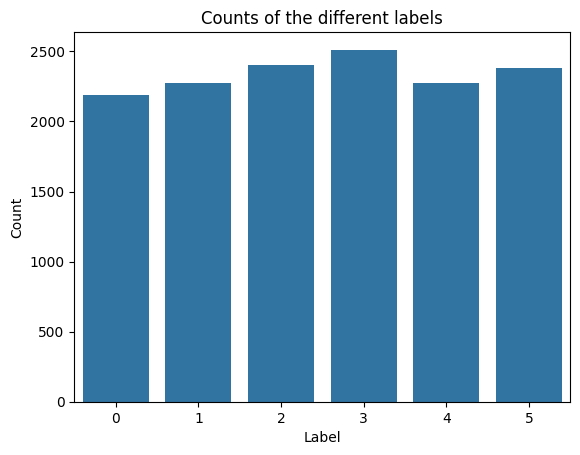

In [6]:
print(f"Images shape:  {images.shape}")
print(f"Labels shape:  {labels.shape}")

seaborn.countplot(x=labels.numpy())
plt.title("Counts of the different labels")
plt.ylabel("Count")
plt.xlabel("Label")
plt.show()

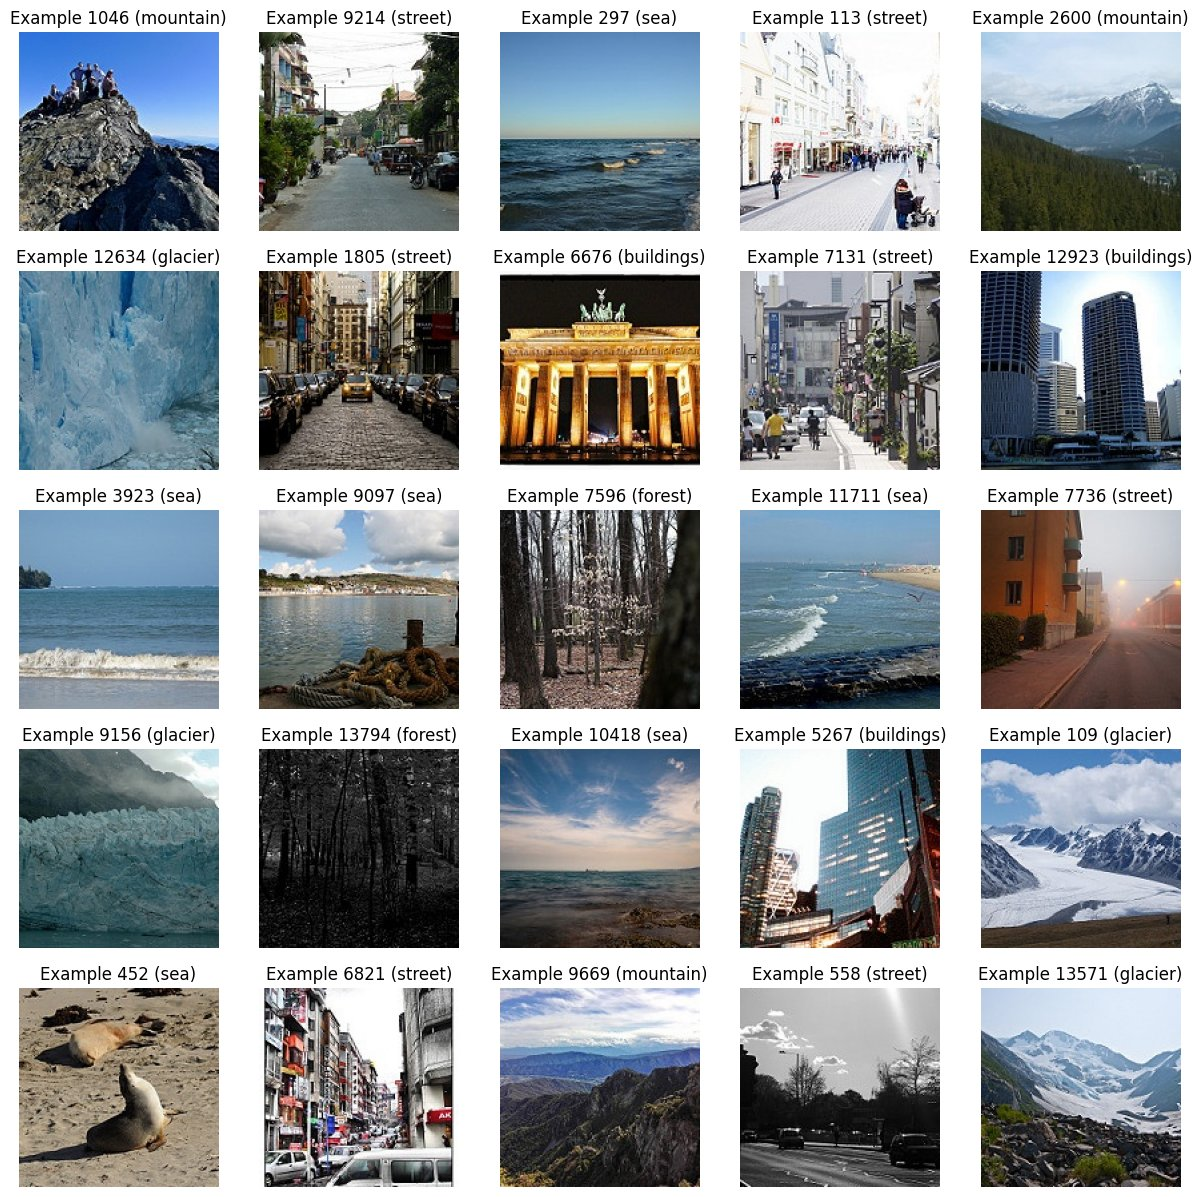

In [7]:
# Create the grid of subplots. We pass the figsize argument to enlarge
# the figure, which is small by default
f, ax = plt.subplots(5, 5, figsize=(15, 15))

# Pick 25 random indices, without replacement (we don't want to display the
# same image twice)
random_indexes = numpy.random.choice(images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    image = images[img_index]
    label = label_names[labels[img_index]]

    # Display with matplotlib and its imshow function, very handy in computer
    # vision
    ax[i, j].imshow(image)
    ax[i, j].set_title(f"Example {img_index} ({label})")
    ax[i, j].axis('off')

## Finetuning a model

In [8]:
#@title Definition of a model
base_model = keras.applications.EfficientNetB0(include_top=False,
                                               weights="imagenet",
                                               input_shape=(150, 150, 3))

base_model.trainable = False

transferred_cnn = keras.Sequential(
    [base_model,
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(1024, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(256, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(64, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(16, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Flatten(),
     keras.layers.Dense(6, activation="softmax", kernel_regularizer="l2")],
    name="transferred_cnn")

transferred_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

transferred_cnn.summary()

Model: "transferred_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 5, 5, 1280)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 1024)     │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 5, 5, 1024)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 256)      │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 5, 5, 256)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 5, 5, 64)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 16)       │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 5, 5, 16)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         2,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,643,609 (21.53 MB)

 Trainable params: 1,594,038 (6.08 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
training = transferred_cnn.fit(images,
                               labels,
                               epochs=5,
                               validation_split=0.30,
                               batch_size=512)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.4171 - loss: 1.6650 - val_accuracy: 0.6682 - val_loss: 1.2570
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 319ms/step - accuracy: 0.6573 - loss: 1.1332 - val_accuracy: 0.7647 - val_loss: 0.8375
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 315ms/step - accuracy: 0.7647 - loss: 0.8144 - val_accuracy: 0.8635 - val_loss: 0.5842
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 319ms/step - accuracy: 0.8274 - loss: 0.6344 - val_accuracy: 0.8912 - val_loss: 0.4697
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 319ms/step - accuracy: 0.8598 - loss: 0.5302 - val_accuracy: 0.9043 - val_loss: 0.4171


## Evaluating the Performance on the Test Set

The `seg_test` folder contains a dataset never seen during training.

We'll use the model's `evaluate(X, y)` method to evaluate the quality of our predictions on this dataset.

In [10]:
test_images,test_labels = get_images(
    pathlib.Path("landscape") / "seg_test")

Processing folders:   0%|          | 0/6 [00:00<?, ?it/s]

Folder buildings:   0%|          | 0/437 [00:00<?, ?it/s]

Folder forest:   0%|          | 0/474 [00:00<?, ?it/s]

Folder glacier:   0%|          | 0/553 [00:00<?, ?it/s]

Folder mountain:   0%|          | 0/525 [00:00<?, ?it/s]

Folder sea:   0%|          | 0/510 [00:00<?, ?it/s]

Folder street:   0%|          | 0/501 [00:00<?, ?it/s]

In [11]:
transferred_cnn.evaluate(test_images, test_labels)

94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 149ms/step - accuracy: 0.8927 - loss: 0.4351


[0.4351485073566437, 0.8926666378974915]

## Error Analysis

We display the confusion matrix, then look at misclassified images.

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step


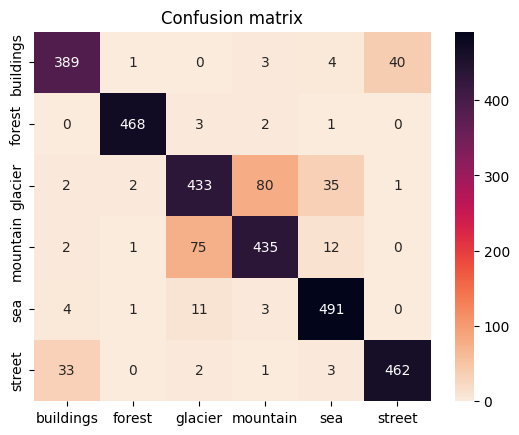

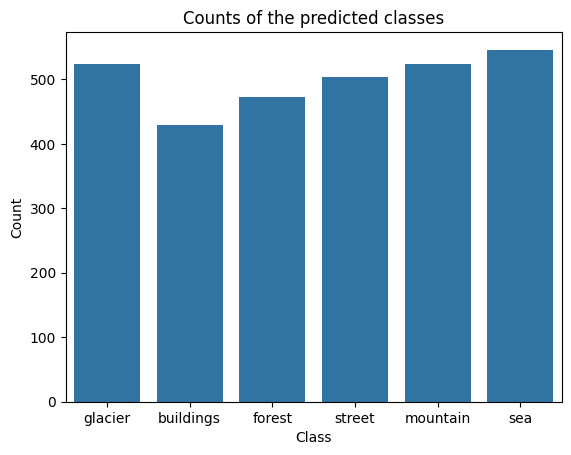

In [12]:
def predict(model: keras.Model, images: tf.Tensor) -> tf.Tensor:
  return tf.math.argmax(model.predict(images), axis=-1)


def analyze_preds(preds: tf.Tensor, labels: tf.Tensor) -> None:
  confusion_matrix = sklearn.metrics.confusion_matrix(labels, preds)
  seaborn.heatmap(confusion_matrix,
                  cmap="rocket_r",
                  xticklabels=label_names,
                  yticklabels=label_names,
                  annot=True,
                  fmt="d")
  plt.title("Confusion matrix")
  plt.show()

  seaborn.countplot(x=[label_names[x] for x in preds])
  plt.title("Counts of the predicted classes")
  plt.ylabel("Count")
  plt.xlabel("Class")
  plt.show()


test_preds = predict(transferred_cnn, test_images)
analyze_preds(test_preds, test_labels)

In [13]:
def plot_mistakes(predicted_class: str,
                  true_class: str,
                  images: tf.Tensor,
                  preds: tf.Tensor,
                  labels: tf.Tensor
                  ) -> None:
  print(f"Prediction: {predicted_class}, true class: {true_class}")
  mistakes = images[(preds == label_to_index[predicted_class])
                         & (labels == label_to_index[true_class])]
  random_indexes = numpy.random.choice(mistakes.shape[0],
                                       size=min(mistakes.shape[0], 25),
                                       replace=False)
  grid_indexes = itertools.product(range(5), repeat=2)

  _, ax = plt.subplots(5, 5, figsize=(15, 15))
  for img_index, (i, j) in zip(random_indexes, grid_indexes):
    ax[i, j].imshow(mistakes[img_index])
    ax[i, j].axis("off")
  plt.show()

Prediction: glacier, true class: mountain


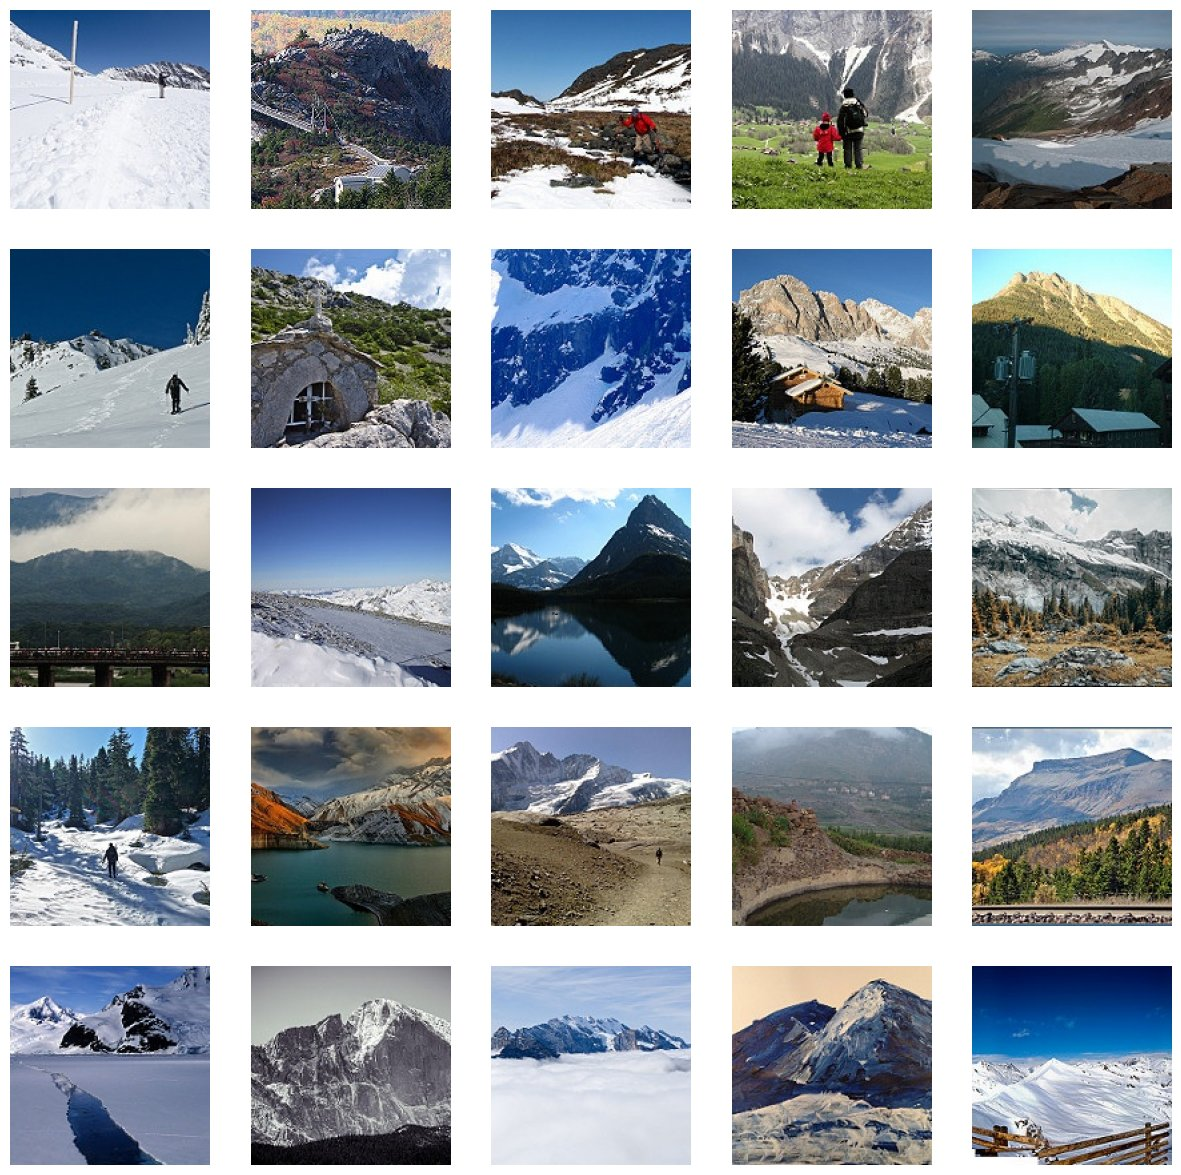

In [14]:
# Plot the images predicted as glacier while their label is mountain
plot_mistakes("glacier", "mountain", test_images, test_preds, test_labels)

Prediction: glacier, true class: sea


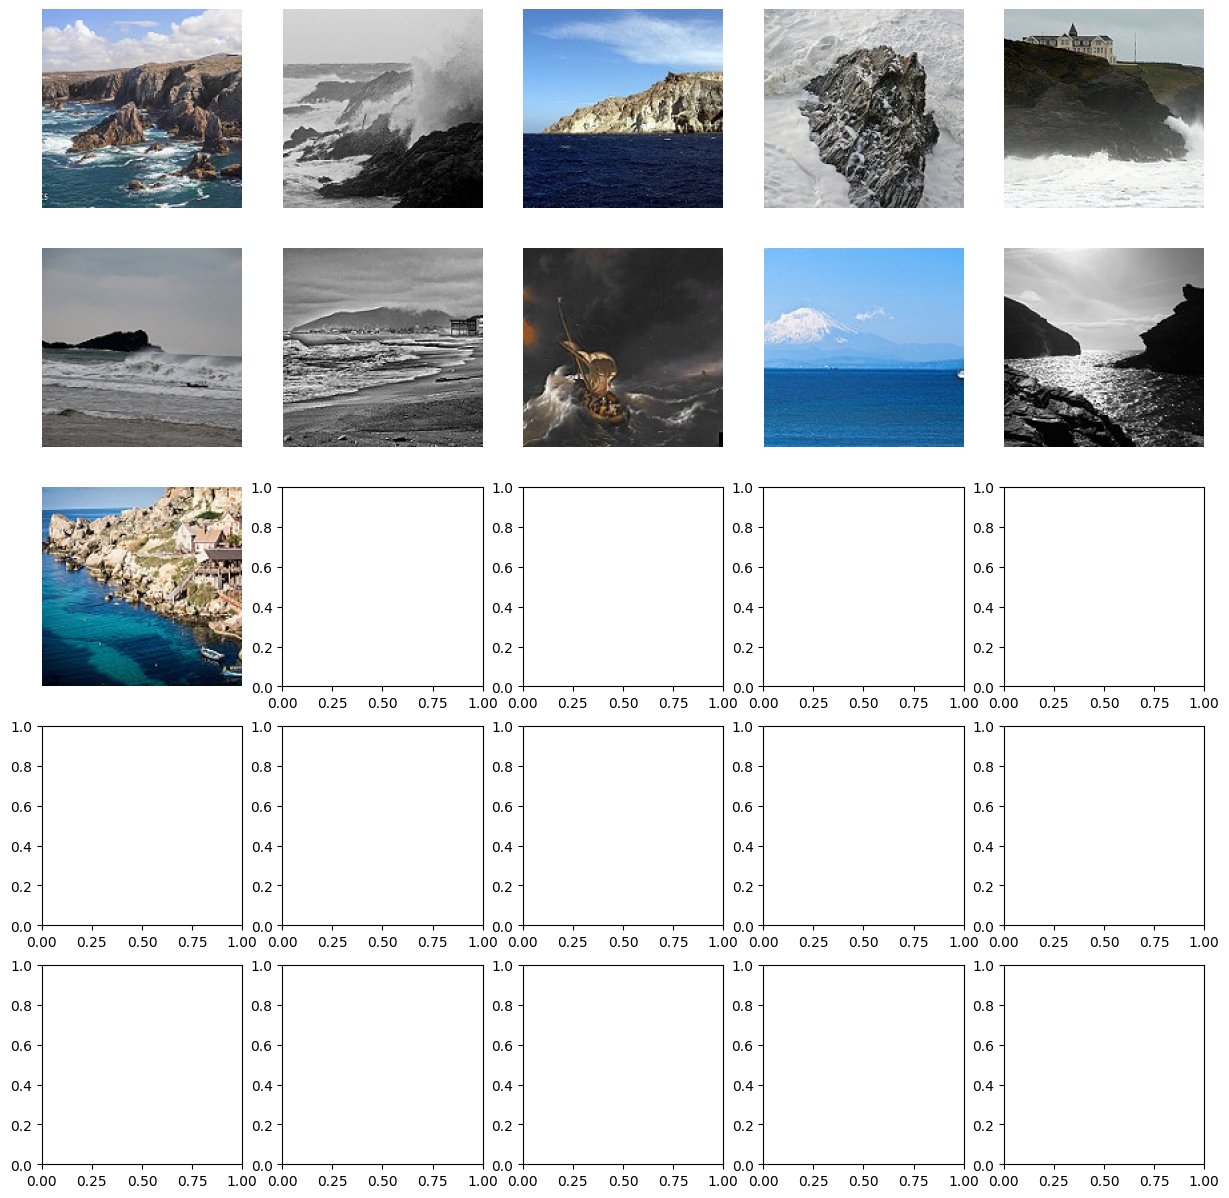

In [15]:
# Plot the images predicted as glacier while their label is sea
plot_mistakes("glacier", "sea", test_images, test_preds, test_labels)

Prediction: buildings, true class: sea


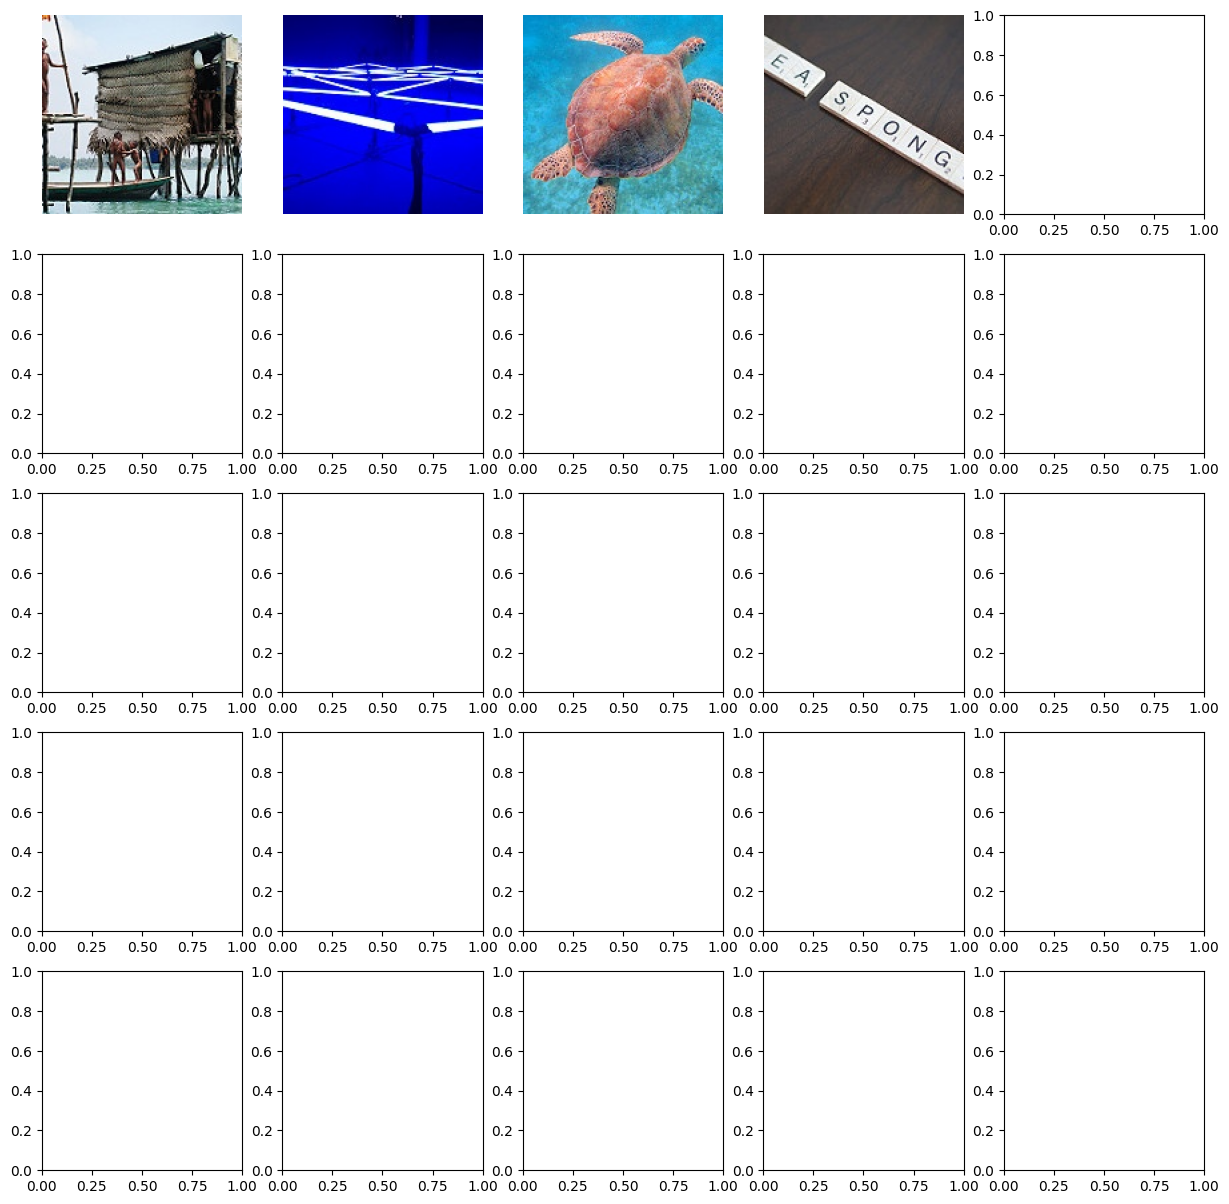

In [16]:
# Plot the images predicted as buildings while their label is sea
plot_mistakes("buildings", "sea", test_images, test_preds, test_labels)

Loss: 0.44, accuracy: 0.89
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


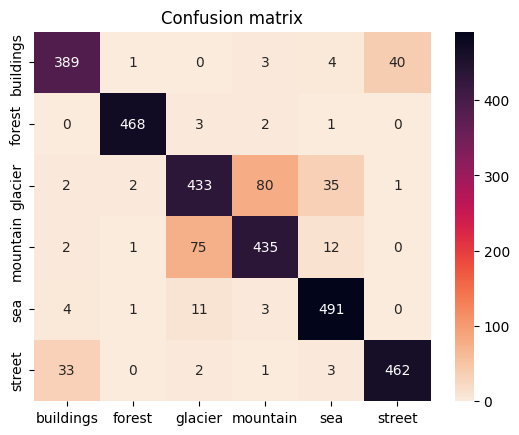

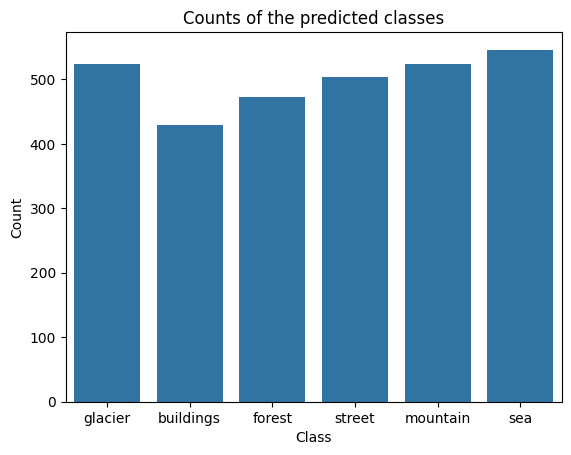

Prediction: glacier, true class: mountain


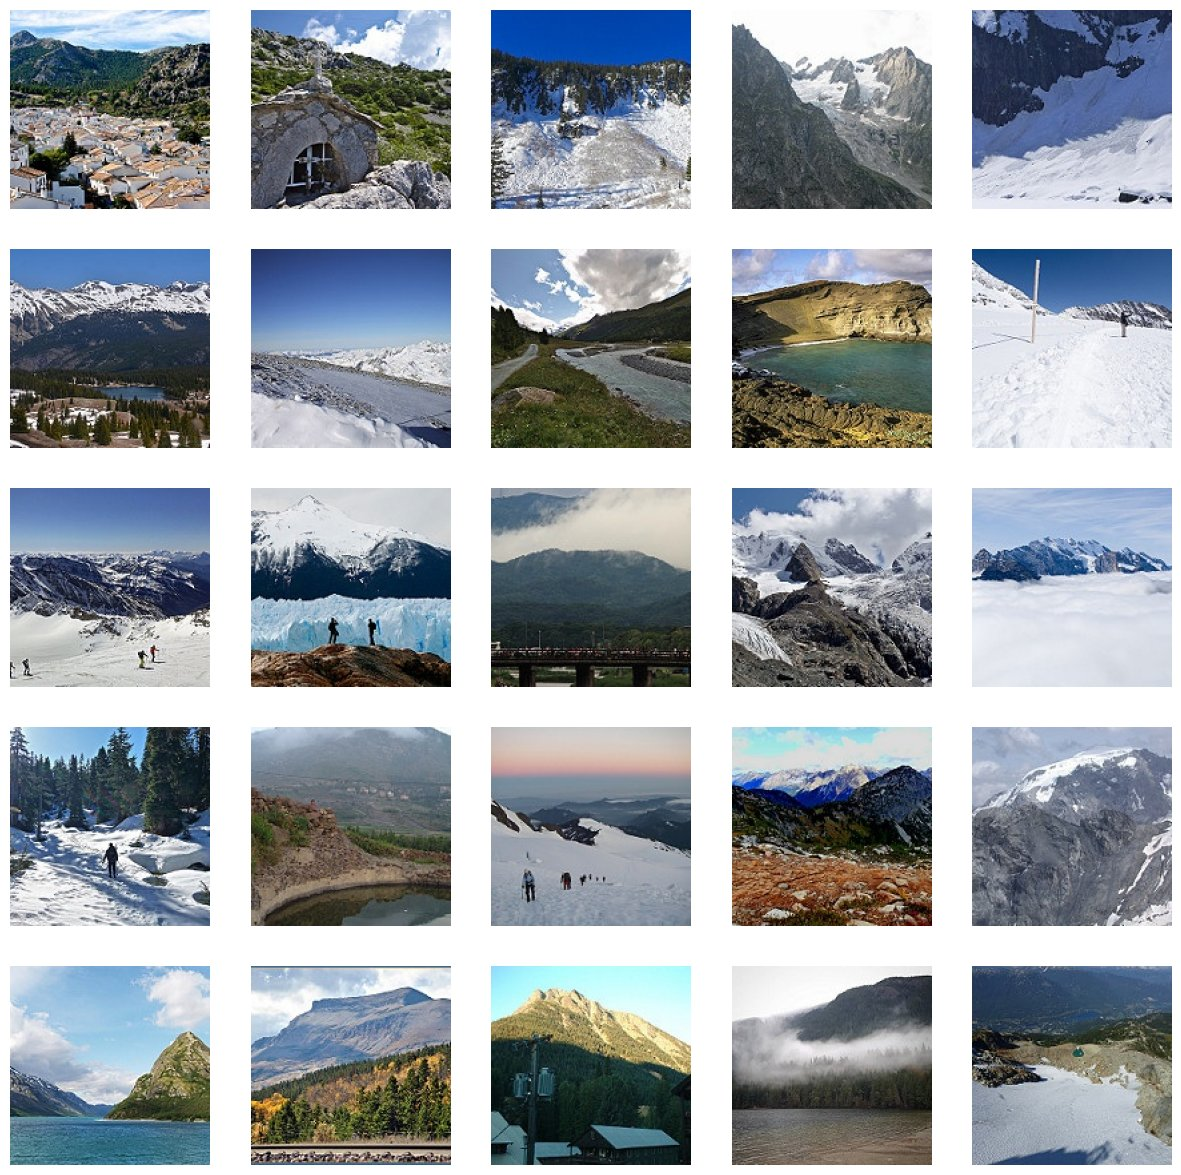

Prediction: glacier, true class: sea


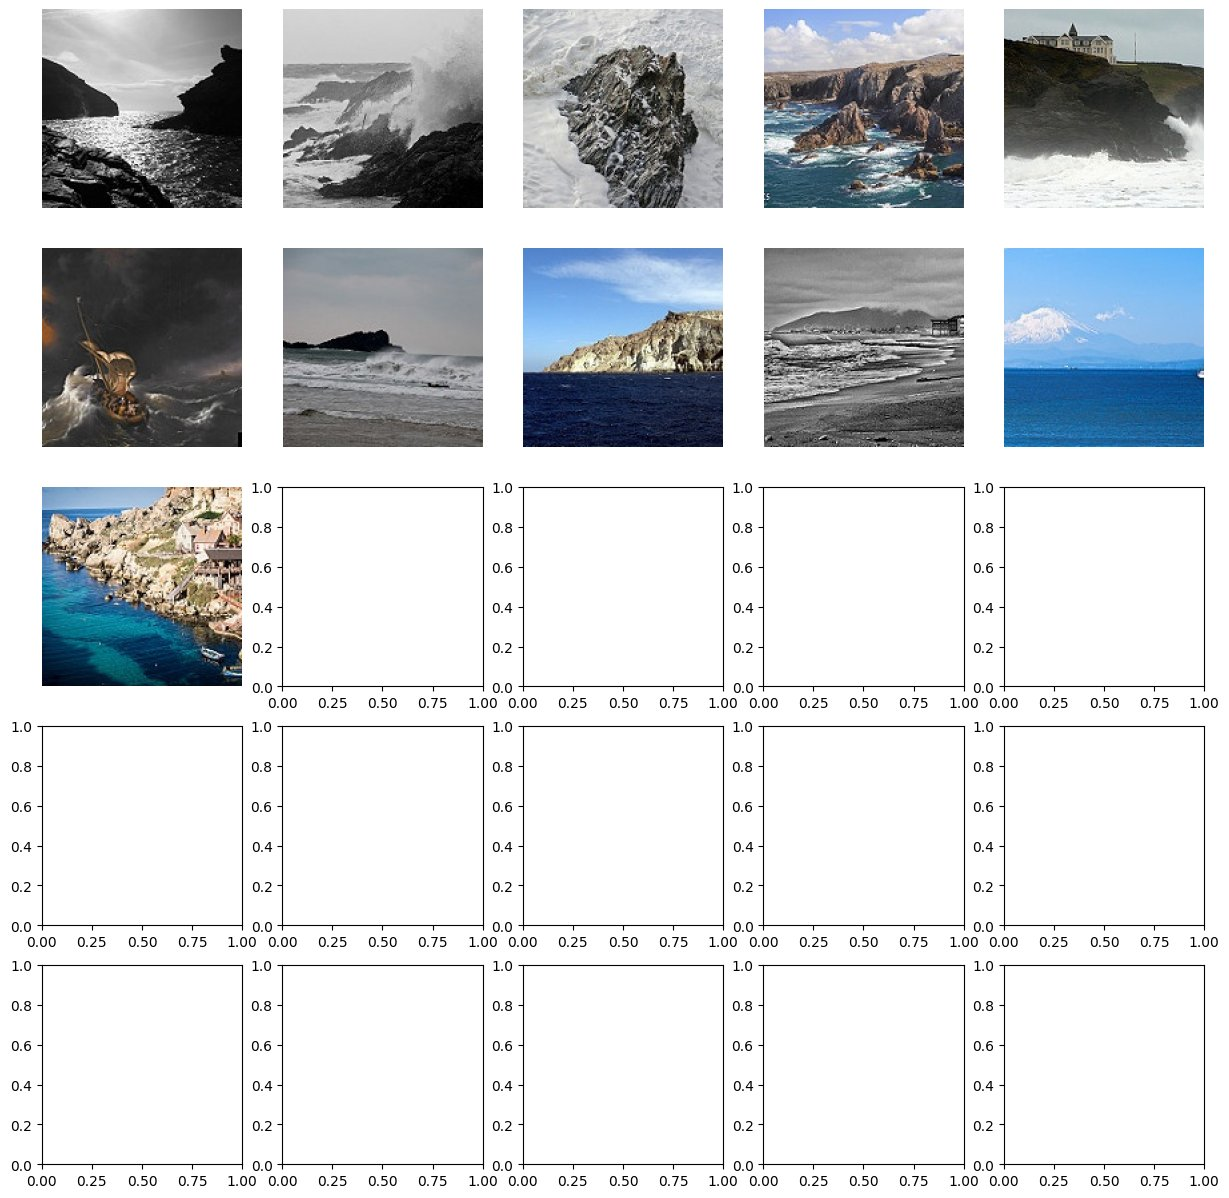

Prediction: buildings, true class: sea


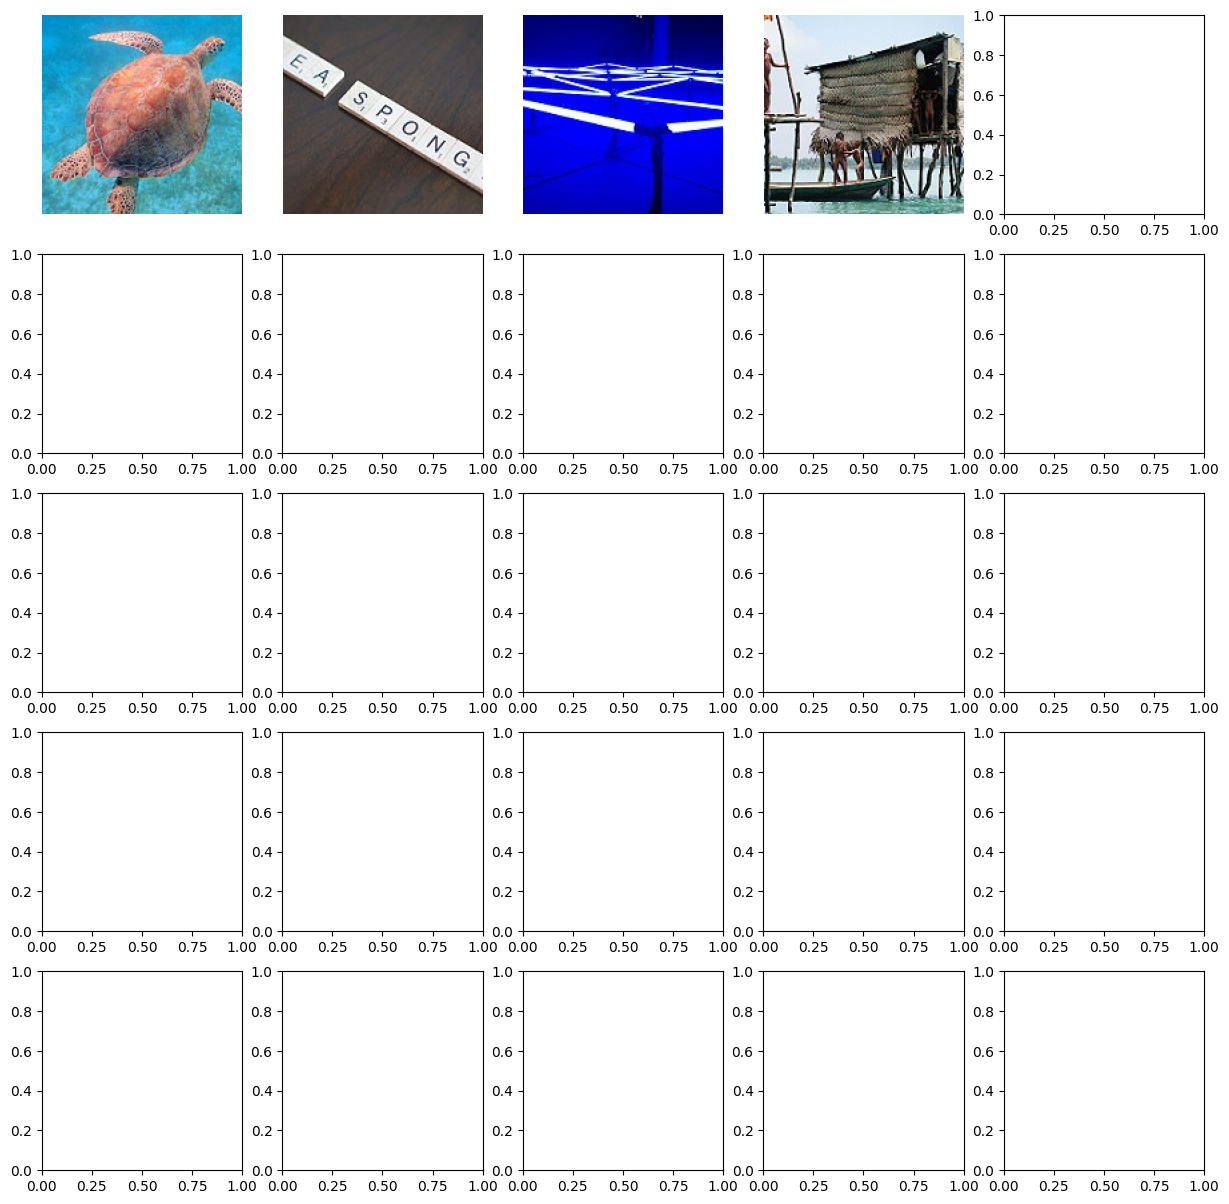

In [17]:
def evaluate(model: keras.Model, images: tf.Tensor, labels: tf.Tensor) -> None:
  loss, accuracy = model.evaluate(images, labels, verbose=False)
  print(f"Loss: {loss:.2f}, accuracy: {accuracy:.2f}")
  preds = predict(model, images)
  analyze_preds(preds, labels)
  plot_mistakes("glacier", "mountain", images, preds, labels)
  plot_mistakes("glacier", "sea", images, preds, labels)
  plot_mistakes("buildings", "sea", images, preds, labels)


evaluate(transferred_cnn, test_images, test_labels)

## Predicting in "Real" Conditions

The `seg_pred` folder contains unannotated images. We therefore can't properly evaluate the performance on this set.

However, we can display photos and the probabilities our model assigns to each class.

In [18]:
pred_images = get_images(
    pathlib.Path("landscape") / "seg_pred",
    create_labels=False)

Processing folders:   0%|          | 0/1 [00:00<?, ?it/s]

Folder no_supervision:   0%|          | 0/7301 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


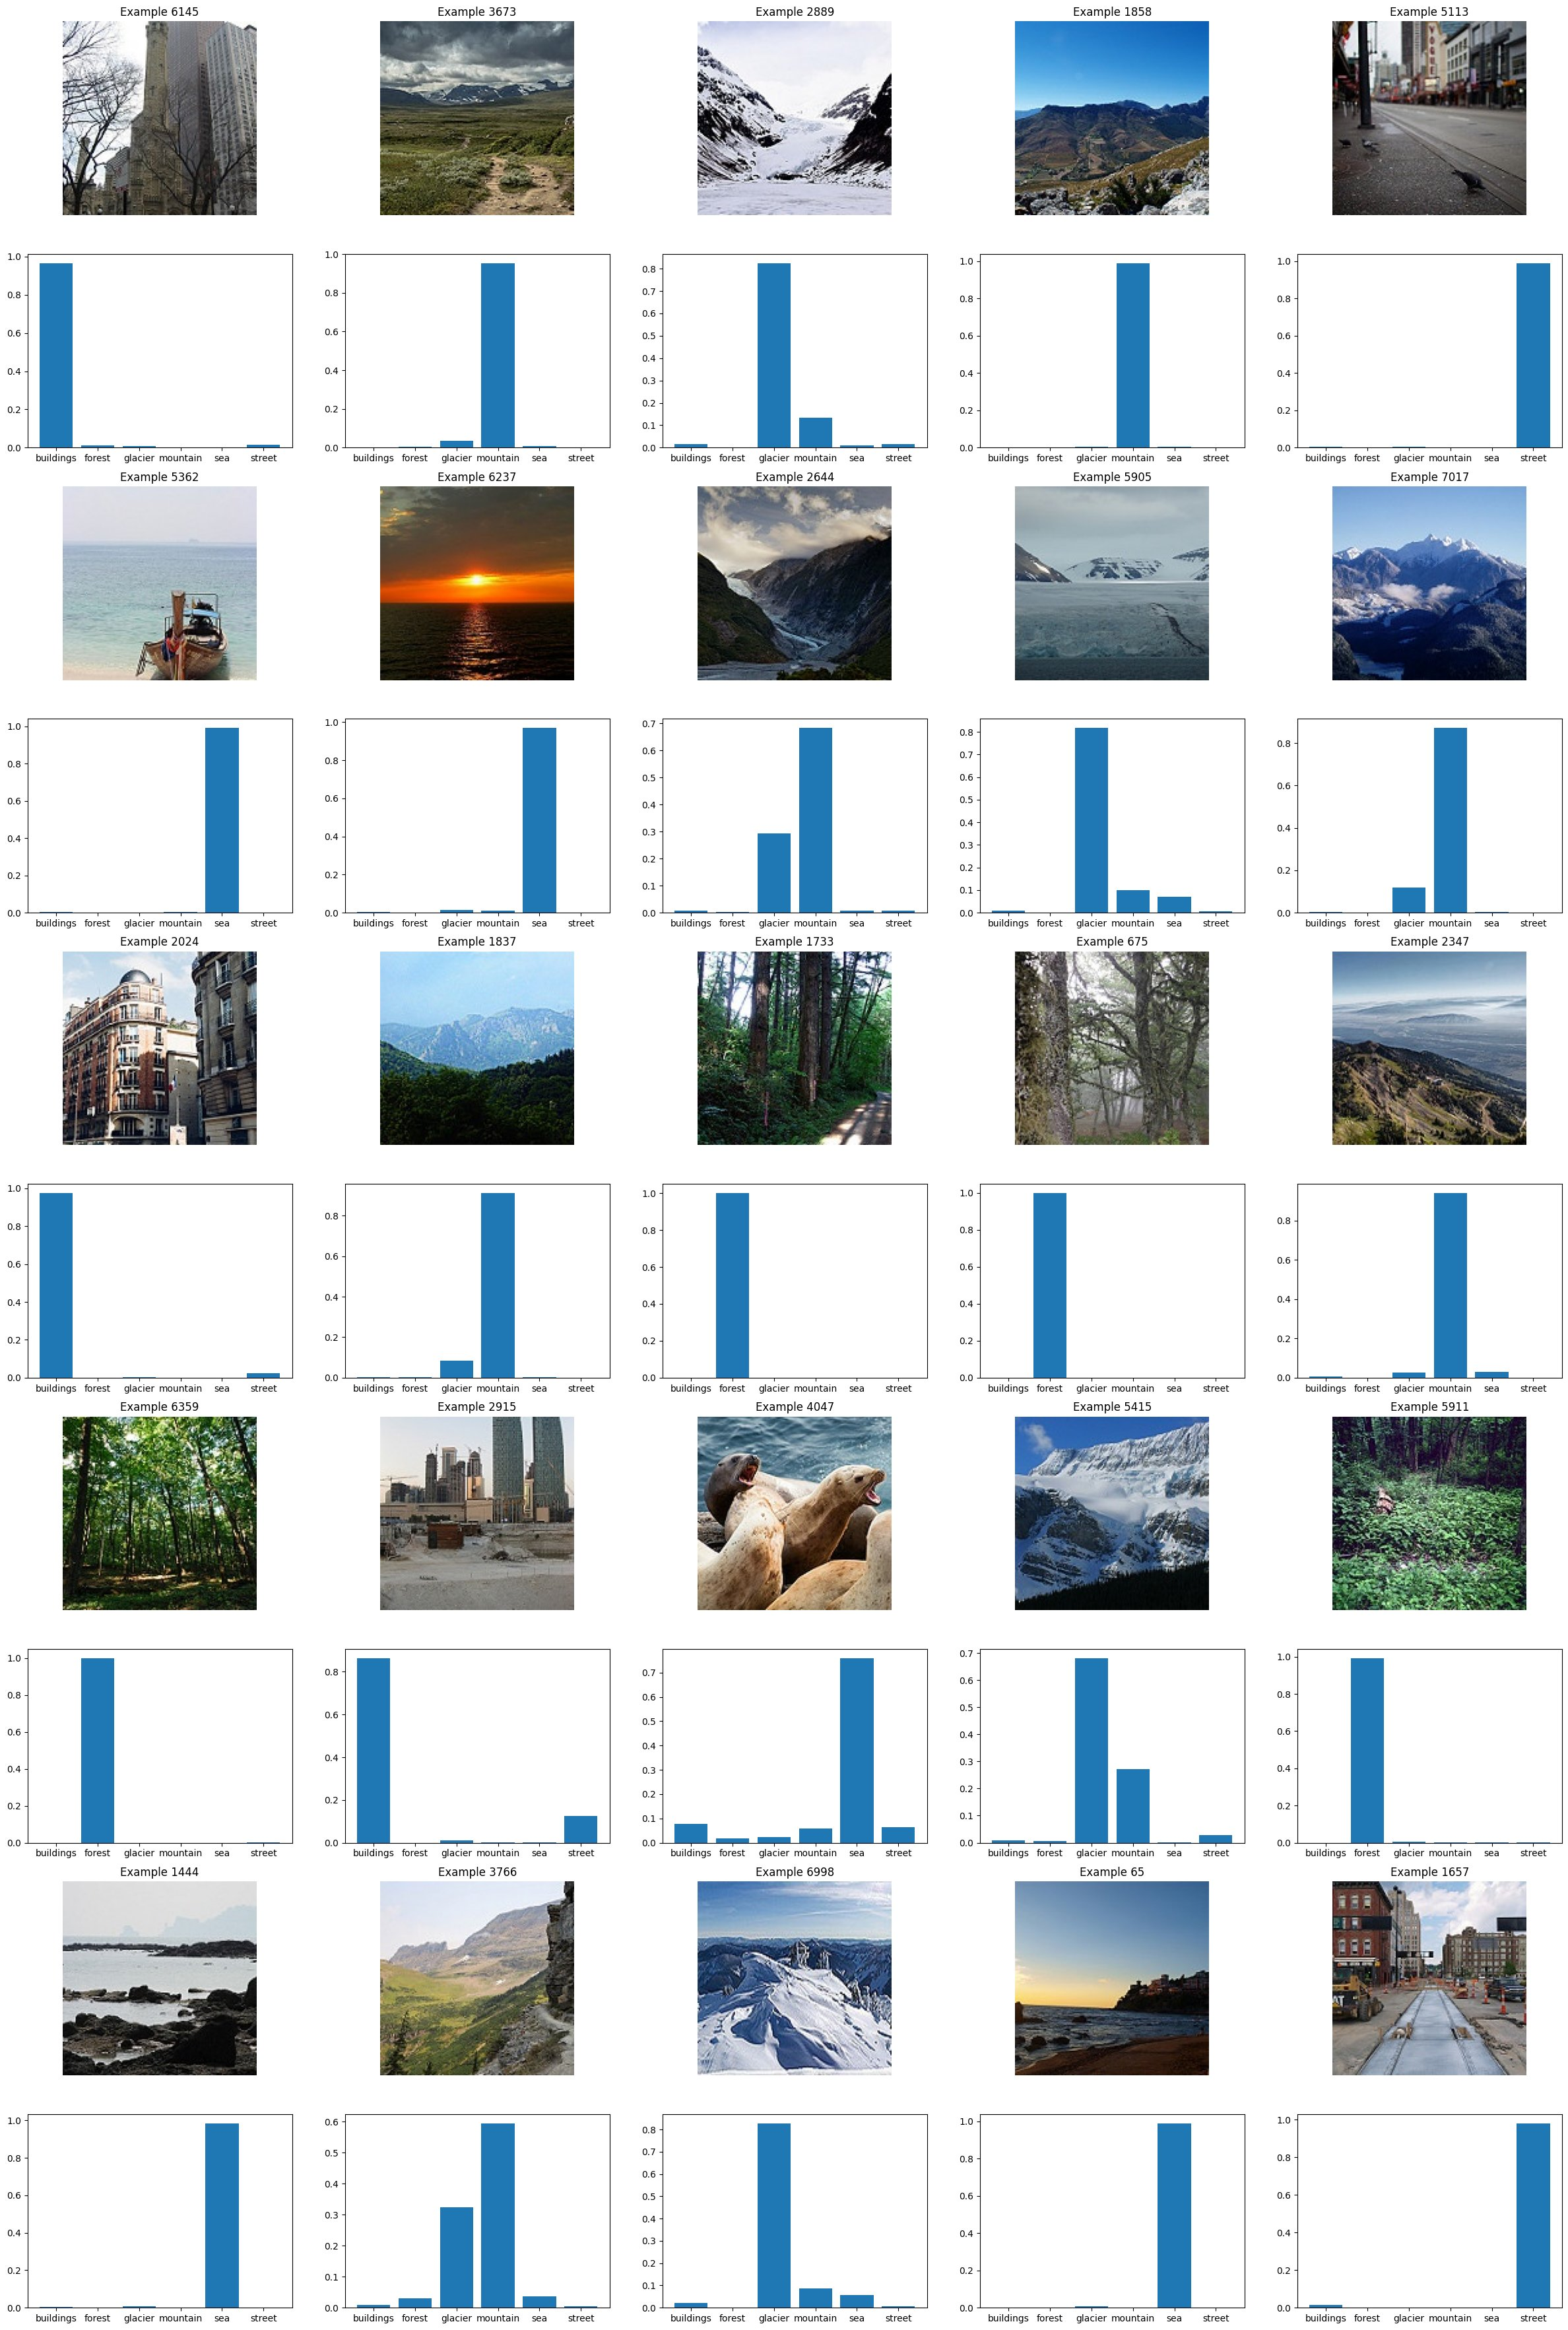

In [19]:
# Create the grid of subplots. We pass the figsize argument to enlarge
# the figure, which is small by default
_, ax = plt.subplots(10, 5, figsize=(30, 45))

# Pick 25 random indices, without replacement (we don't want to display the
# same image twice)
random_indexes = numpy.random.choice(pred_images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    # Get the image and predict its class
    image = pred_images[img_index]
    probabilities = transferred_cnn.predict(image[None, ...])[0]
    predicted_class = label_names[numpy.argmax(probabilities)]

    # Display with matplotlib and its imshow function, very handy in computer
    # vision
    ax[i * 2, j].imshow(image)
    ax[i * 2, j].set_title(f"Example {img_index}")
    ax[i * 2, j].axis('off')

    # Display the prediction distribution on the row below
    ax[i * 2 + 1, j].bar(label_names, probabilities)

## Model interpretability with SHAP

SHAP (Shapley values) assigns each input variable its contribution to one prediction: how much it pushed the model towards a class, or away from it. For an image, the "variables" are regions of the image: SHAP blurs some of them, looks at how the prediction changes, and deduces what each region brings. The method comes from game theory (Lloyd Shapley), where it shares a payoff among the players of a team.

Let's explain the errors seen above: the mountains the model took for glaciers.

In [20]:
# The mountain images the model took for glaciers
glacier_for_mountain = tf.boolean_mask(
    test_images,
    (test_preds == label_to_index["glacier"]) & (test_labels == label_to_index["mountain"]))
print(f"{glacier_for_mountain.shape[0]} mountains predicted as glacier")

masker = shap.maskers.Image("blur(32,32)", test_images[0].shape)

explainer = shap.Explainer(transferred_cnn.predict, masker, output_names=label_names)

# We explain the two classes at stake: "glacier" (predicted) and "mountain" (true)
shap_values = explainer(
    glacier_for_mountain[:6].numpy(), max_evals=1_000, batch_size=50,
    outputs=[label_to_index["glacier"], label_to_index["mountain"]]
)

75 mountains predicted as glacier
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


  0%|          | 0/998 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


PartitionExplainer explainer:  17%|█▋        | 1/6 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


...

PartitionExplainer explainer:  83%|████████▎ | 5/6 [01:33<00:03,  3.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


PartitionExplainer explainer: 100%|██████████| 6/6 [01:37<00:00,  3.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


PartitionExplainer explainer: 7it [01:41, 16.93s/it]


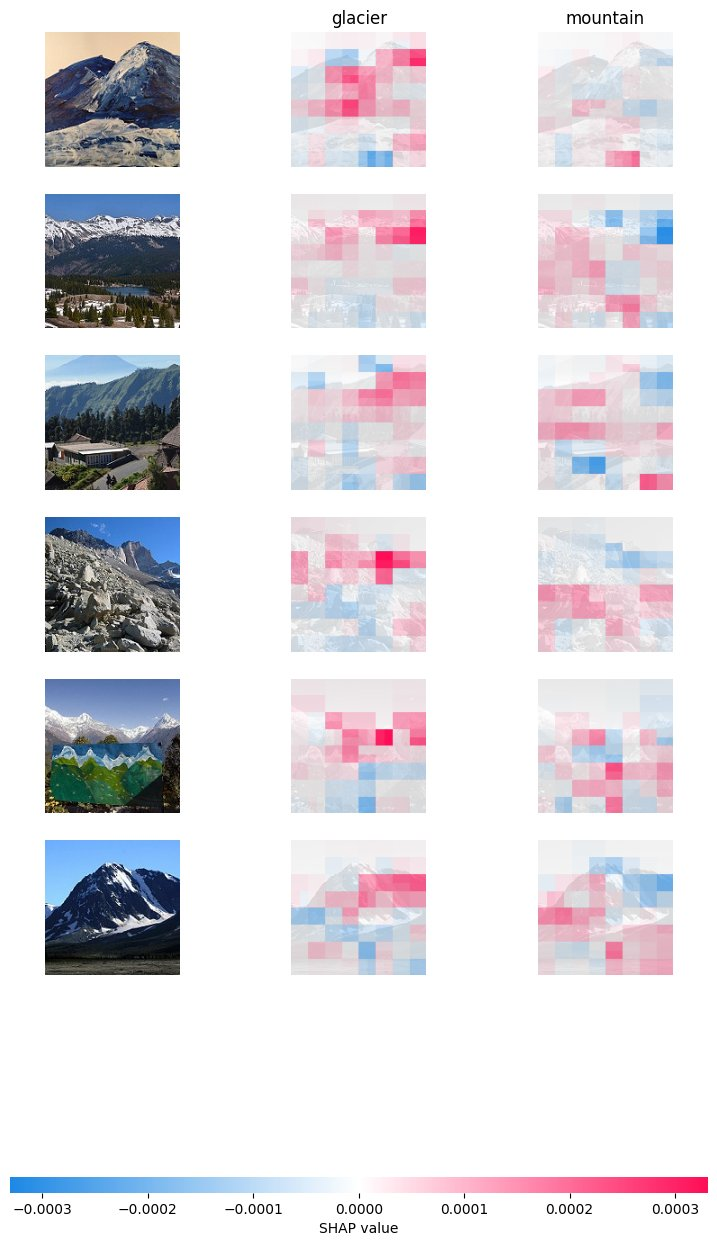

In [21]:
shap.image_plot(shap_values)

How to read the figure: each row is a misclassified image. The "glacier" column shows the regions that pushed the model towards "glacier" (in red) or away from it (in blue); the "mountain" column does the same for the true class.

**Questions:**

- Which regions of the images pushed the model towards "glacier"?
- For each image, does the error come from the model, or from the labelling (an image a human would also hesitate to classify)?

### Answer elements

- In the "glacier" column, the red gathers at the top of the images: the peaks and ridges, often snowy, that stand out against the sky. The bottom of the images (forest, rocks, buildings) weighs little, or pushes away from "glacier". The model associates "glacier" with bright reliefs against the sky, which snowy mountains have too.
- Many of these "mountains" are snowy peaks, or even mountain glaciers: a human would hesitate too. The two classes overlap, and nothing in the data says where the boundary lies. This is a labelling problem: you address it by clarifying the annotation guide (for instance "glacier if ice covers most of the image") and relabelling the ambiguous cases, not by changing the model.
- If the red regions fall on an unrelated detail (an edge of the image, a plain sky), the model relies on a wrong cue: it needs more varied examples (or data augmentation), or a better model. That's not the case here: the red regions do fall on the relief.
- Limits: SHAP blurs squares of the image, so its explanation is coarse (blocks, not outlines). And six images aren't enough: look at several before concluding.

## SHAP on structured data

Let's switch problems: predicting the sale price of houses in Ames (Iowa, USA) from their characteristics (area, quality, neighbourhood…). Let's start by fetching the data, then train a random forest while keeping 20% of the houses aside, to measure its errors on houses it has never seen:

In [22]:
#@title Getting and processing structured data
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s ames
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn
import sklearn.ensemble
import sklearn.model_selection
import scipy.stats
import warnings
warnings.filterwarnings('ignore')

def preprocess(train_file, test_file):
    train_X = pandas.read_csv(train_file, index_col="Id")
    test_X = pandas.read_csv(test_file, index_col="Id")

    train_y = train_X.pop("SalePrice")

    all_X = pandas.concat([train_X, test_X])

    # Fill with median
    cols_1 = ["LotFrontage"]
    all_X[cols_1] = all_X[cols_1].fillna(train_X[cols_1].median())

    # Fill with mode
    cols_2 = ["MSZoning", "Electrical", "KitchenQual", "Exterior1st",
             "Exterior2nd", "SaleType", "Utilities"]
    all_X[cols_2] = all_X[cols_2].fillna(train_X[cols_2].mode().iloc[0, :])

    # Fill with 0
    cols_4 = ["GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1",
              "BsmtFinSF2", "BsmtFullBath", "BsmtHalfBath", "BsmtUnfSF",
              "MasVnrArea", "TotalBsmtSF"]
    all_X[cols_4] = all_X[cols_4].fillna(0)

    # Other fills
    cols_5 = ["Functional"]
    all_X[cols_5] = all_X[cols_5].fillna("Typ")

    all_X = all_X.fillna("NA")

    cols_numerical2label = ['MSSubClass']
    all_X[cols_numerical2label] = all_X[cols_numerical2label].astype(str)

    quality_mapping = dict(NA=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5)
    quality_columns = ["BsmtCond", "BsmtQual", "ExterCond", "ExterQual",
                       "FireplaceQu", "GarageCond", "GarageQual", "HeatingQC",
                       "KitchenQual", "PoolQC"]
    street_mapping = dict(NA=0, Grvl=1, Pave=2)
    bsmt_fin_mapping = dict(NA=0, Unf=1, LwQ=2, Rec=3, BLQ=4, ALQ=5, GLQ=6)

    replace_mapping = dict(
      Alley=street_mapping,
      BsmtExposure=dict(NA=0, No=1, Mn=2, Av=3, Gd=4),
      BsmtFinType1=bsmt_fin_mapping,
      BsmtFinType2=bsmt_fin_mapping,
      Functional=dict(Sal=1, Sev=2, Maj2=3, Maj1=4, Mod=5, Min2=6, Min1=7, Typ=8),
      LandSlope=dict(Sev=1, Mod=2, Gtl=3),
      LotShape=dict(IR3=1, IR2=2, IR1=3, Reg=4),
      PavedDrive=dict(NA=0, N=1, P=2, Y=3),
      Street=dict(Grvl=1, Pave=2),
      Utilities=dict(ELO=1, NoSeWa=2, NoSewr=3, AllPub=4),
    )

    for quality_column in quality_columns:
      replace_mapping[quality_column] = quality_mapping

    all_X.replace(replace_mapping, inplace=True)

    print(f"Number of NAs : {all_X.isnull().sum().sum()}")

    dummies = pandas.get_dummies(all_X)
    return (dummies.iloc[:train_X.shape[0], :],
            train_y,
            dummies.iloc[train_X.shape[0]:, :])

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 2), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 422.90 KiB | 2.92 MiB/s, done.
Resolving deltas: 100% (2/2), done.
✓ ames — 8 fichiers, 4.6M


In [23]:
X, y, _ = preprocess("ames/train.csv", "ames/test.csv")

Number of NAs : 0


In [24]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, random_state=0)
rfr = sklearn.ensemble.RandomForestRegressor(random_state=0, n_jobs=-1)
rfr.fit(X_train, y_train)

errors = (y_test - rfr.predict(X_test)).abs()
print(f"Mean error on the test houses: ${errors.mean():,.0f} "
      f"(mean price: ${y_test.mean():,.0f})")

Mean error on the test houses: $17,065 (mean price: $181,370)


## Global explanation

We compute the Shapley values of each variable for each test house, then their mean (in absolute value): that's the variable's global importance for the model.

In [25]:
explainer = shap.TreeExplainer(rfr)
explanation = explainer(X_test)

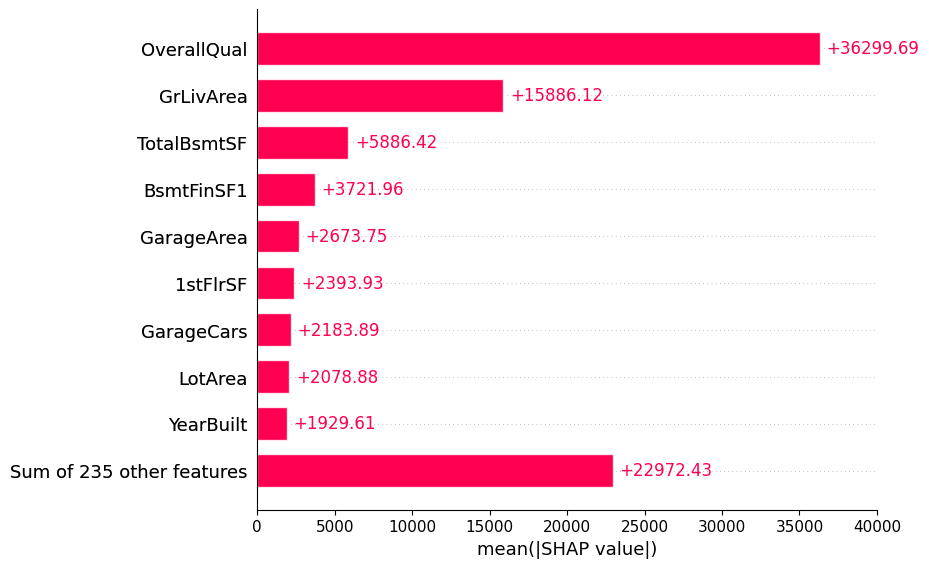

In [26]:
shap.plots.bar(explanation)

**Question:** which are the 3 most important variables? Do they make sense for the price of a house?

### Answer elements

- `OverallQual` (the house's overall quality, a 1-to-10 rating given by an assessor), `GrLivArea` (the living area) and `TotalBsmtSF` (the basement area): quality and size. That fits what we know about real-estate prices.
- `OverallQual` dwarfs the others: this rating already sums up a lot (materials, finishes…). Check that it will be available when predicting: if the model must price an online listing, with no assessment, it loses its main variable.
- A categorical variable, such as the neighbourhood, is split into one 0/1 column per value (`Neighborhood_...`): its importance is spread across these columns, which must be added up to judge it.
- SHAP explains the model, not the market: a variable that matters to the model isn't necessarily a cause of the price.

## Local explanation

Let's compare the test house the model predicts worst with a house it predicts well. For one house, SHAP starts from the mean predicted price (at the bottom of the chart, $E[f(X)]$) and adds each variable's contribution (in red if it raises the price, in blue if it lowers it), up to the predicted price (at the top, $f(x)$).

House 1299: actual price $160,000, predicted price $481,143


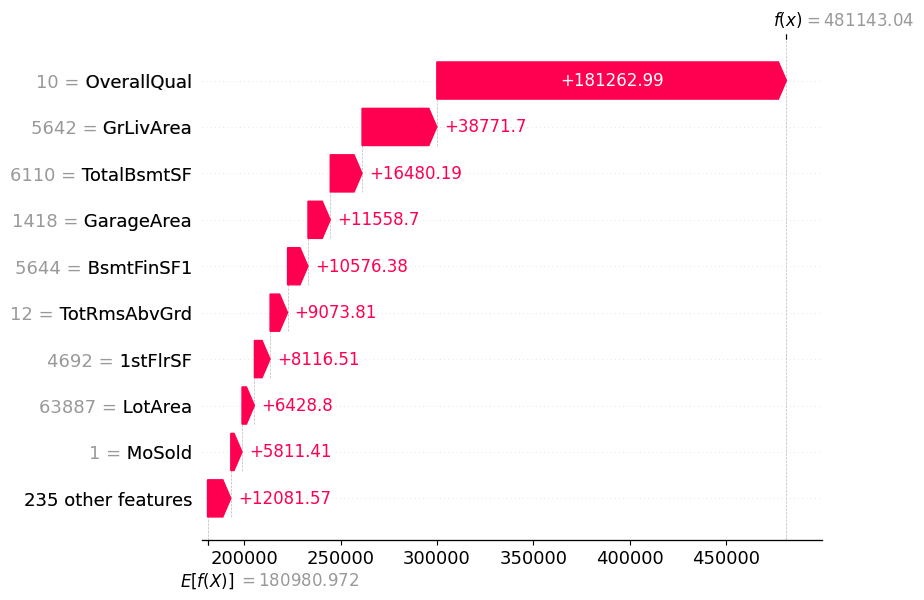

In [27]:
def explain_house(house_id: int) -> None:
  position = X_test.index.get_loc(house_id)
  print(f"House {house_id}: actual price ${y_test[house_id]:,.0f}, "
        f"predicted price ${rfr.predict(X_test.iloc[[position]])[0]:,.0f}")
  shap.plots.waterfall(explanation[position])


worst = errors.idxmax()
explain_house(worst)

House 460: actual price $110,000, predicted price $110,042


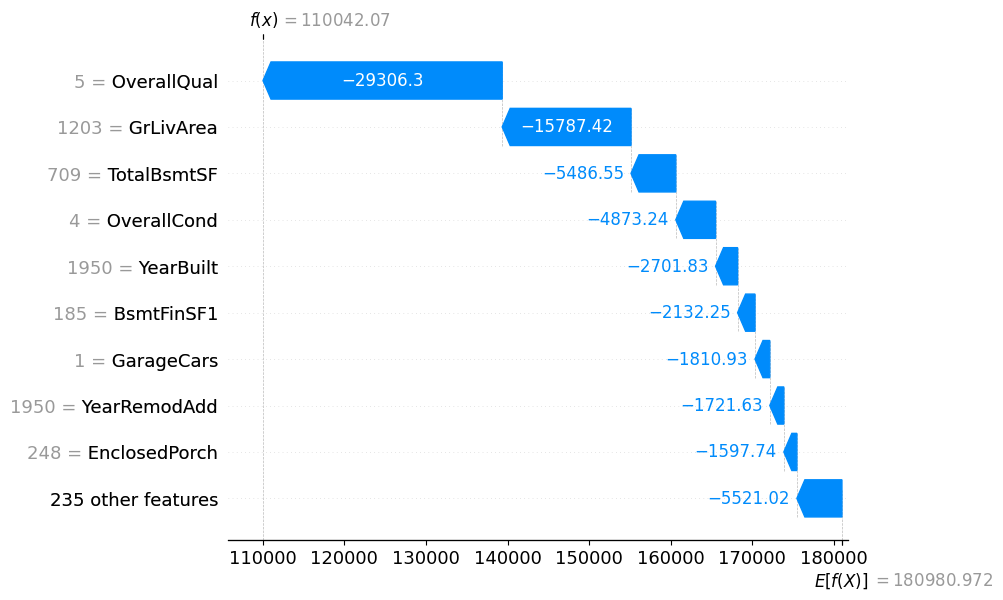

In [28]:
well_predicted = errors.idxmin()
explain_house(well_predicted)

In [29]:
# A few columns of the original data, before preprocessing
raw = pandas.read_csv("ames/train.csv", index_col="Id")
raw.loc[[worst, well_predicted],
        ["OverallQual", "GrLivArea", "TotalBsmtSF", "LotArea", "SaleCondition", "SalePrice"]]

,OverallQual,GrLivArea,TotalBsmtSF,LotArea,SaleCondition,SalePrice
Id,,,,,,
1299,10,5642,6110,63887,Partial,160000
460,5,1203,709,7015,Normal,110000


**Questions:**

- Why is the model so wrong about the first house? Is it a model problem or a data problem?
- What sets apart the explanation of the well-predicted house?

### Answer elements

- The worst-predicted house (no. 1299) has everything of a very expensive house: top quality (10), over 5,600 square feet of living area (about 520 m²), a huge basement and lot. SHAP shows that `OverallQual` and `GrLivArea` raise its prediction by over \$200,000 above the mean: the model reasoned "normally".
- Yet it sold for \$160,000: it's a partial sale (`SaleCondition = Partial`, a new house sold before it was completed). The dataset's author, Dean De Cock, flags these few very large, atypical houses himself and advises removing them. This is a data problem, not a model problem: check the record, then exclude it or add the missing information, rather than change the model.
- The well-predicted house (no. 460, sold for \$110,000) is a modest house: average quality (5), 1,200 square feet of living area (about 110 m²). The same variables, `OverallQual` and `GrLivArea` first, now lower its prediction, and all the contributions go the same way, with no extreme value: a common profile in the data, which the model knows well.
- General method: examine the largest errors one by one, with their explanation. They often reveal outliers or data-entry mistakes.

## Key takeaways

- Error analysis starts with the confusion matrix, then with examining the misclassified examples: that's where you find out whether the problem lies in the model or in the data.
- SHAP (Shapley values) explains one prediction: the contribution of each variable, or of each region of an image. Their mean over many examples gives the variables' global importance.
- An explanation lets you check that the model relies on sensible cues, and spot variables unavailable in production or outliers.
- SHAP explains the model, not reality: an important variable isn't necessarily a cause.
- Many errors come from the labels or the data (overlapping classes, atypical sales): you fix them in the data and in the annotation guide, not by changing the model.